In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
import numpy as np

In [2]:
data = pd.read_csv("data_full_story.csv")

data.head()

,name,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
0,t1_c95k50u,0.000000,1.0,1.0,1.000000,2.75,2.25,1.75
1,t1_c95mz3n,0.857143,4.0,5.0,1.000000,2.75,2.75,3.25
2,t1_c95l4my,0.857143,4.0,4.0,1.000000,2.75,3.25,3.50
3,t1_c95mcms,0.857143,5.0,5.0,1.000000,3.25,4.00,2.50
4,t3_1aenyc,1.000000,5.0,5.0,3.666667,2.75,3.50,3.75


In [3]:
dependent = data["story_score"]

independent_vars = [
    "agency_score",
    "event_score",
    "world_score",
    "curiosity_score",
    "surprise_score",
    "suspense_score"
]

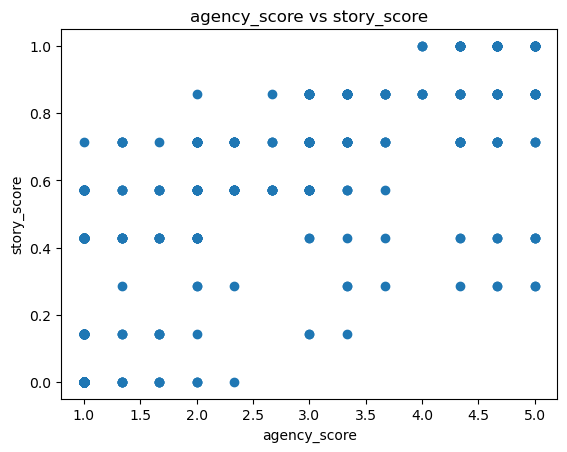

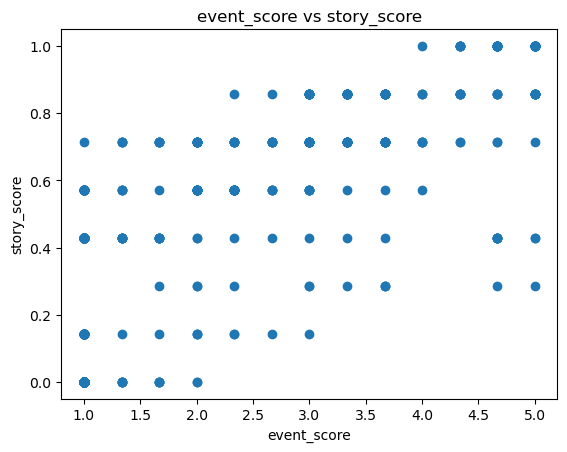

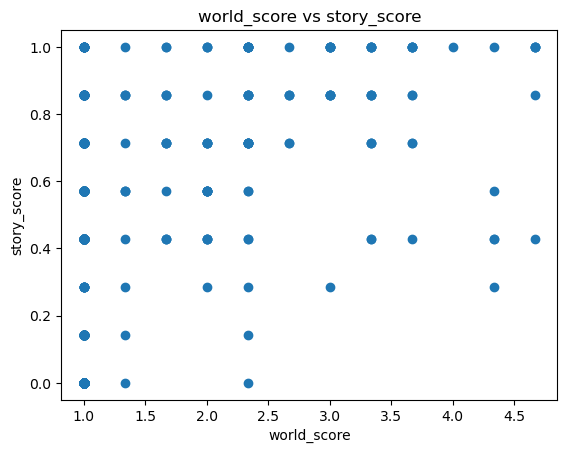

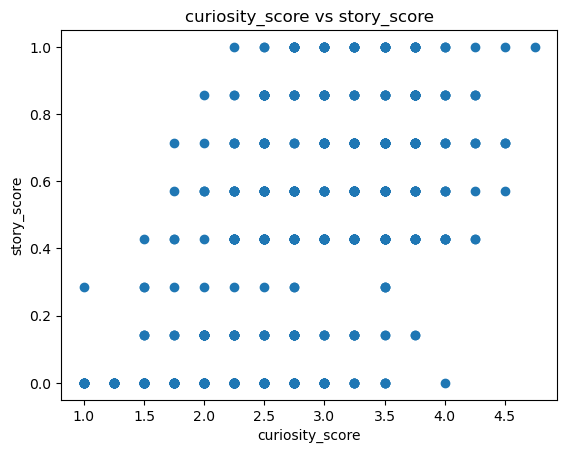

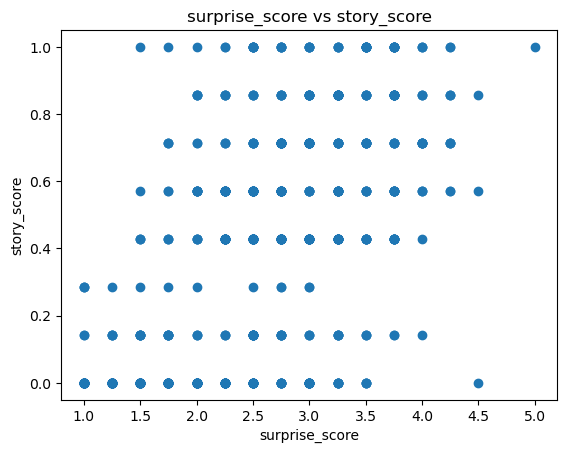

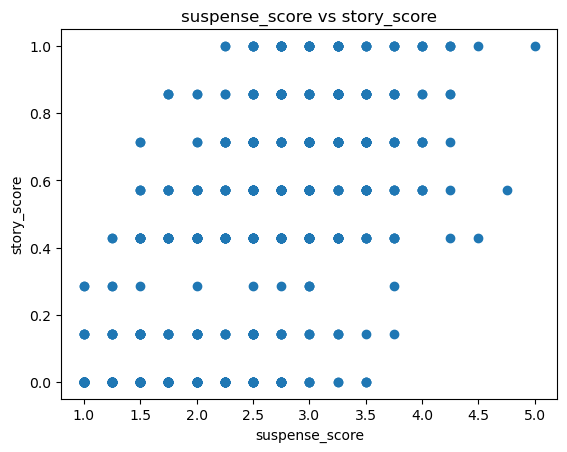

In [4]:
for var in independent_vars:
    plt.figure()
    plt.scatter(data[var], dependent)
    plt.xlabel(var)
    plt.ylabel("story_score")
    plt.title(f"{var} vs story_score")
    plt.show()


Variable: agency_score
Slope: 0.18627994385726152
Intercept: 0.02436967505067339


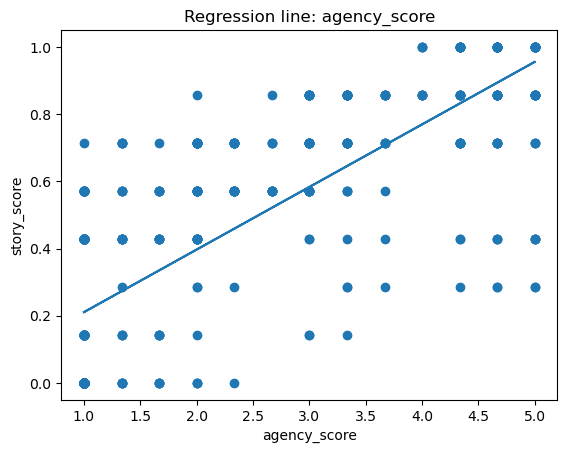


Variable: event_score
Slope: 0.19334793892265859
Intercept: 0.020186836862851387


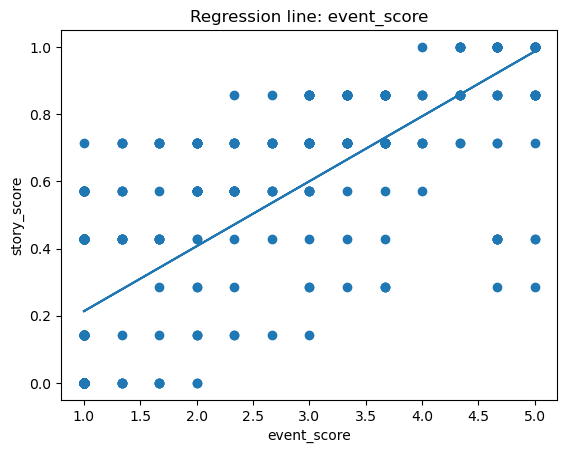


Variable: world_score
Slope: 0.2019724466138093
Intercept: 0.1454102280754262


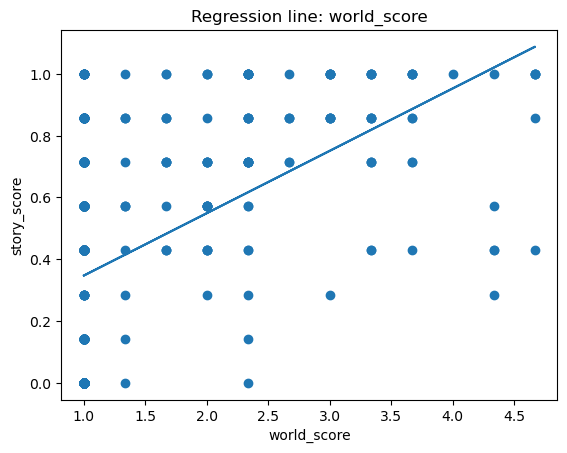


Variable: curiosity_score
Slope: 0.26549191225110264
Intercept: -0.3194731612449244


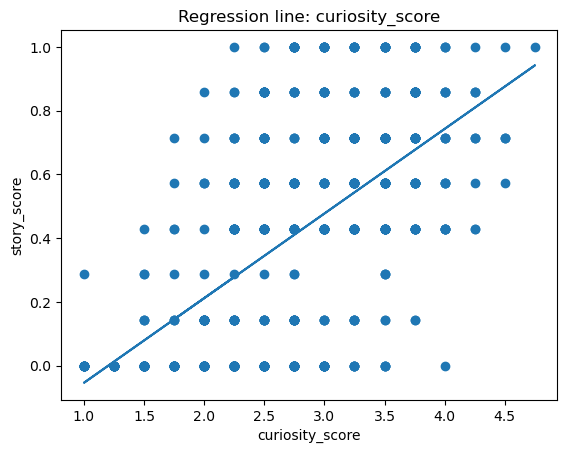


Variable: surprise_score
Slope: 0.23856645776524987
Intercept: -0.2014076830342444


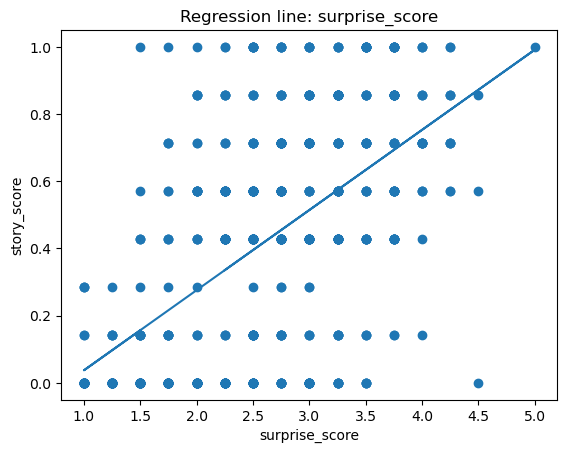


Variable: suspense_score
Slope: 0.2575710705260038
Intercept: -0.21450119998638406


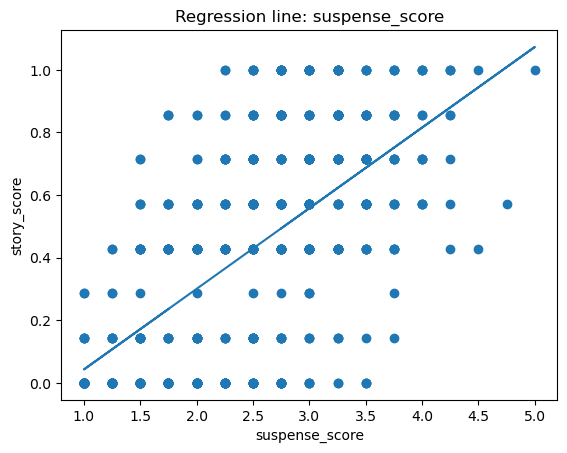

In [5]:
for var in independent_vars:

    X = data[[var]]
    y = dependent

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_

    print(f"\nVariable: {var}")
    print("Slope:", slope)
    print("Intercept:", intercept)

    plt.figure()
    plt.scatter(X, y)
    plt.plot(X, predictions)
    plt.xlabel(var)
    plt.ylabel("story_score")
    plt.title(f"Regression line: {var}")
    plt.show()

In [6]:
for var in independent_vars:

    X = data[[var]]
    y = dependent

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    r2 = r2_score(y, predictions)

    print(f"{var} R2 score:", r2)

agency_score R2 score: 0.580823110283913
event_score R2 score: 0.5971390119224571
world_score R2 score: 0.20441831933988508
curiosity_score R2 score: 0.36142282050508
surprise_score R2 score: 0.3427290841563504
suspense_score R2 score: 0.42143072641120327


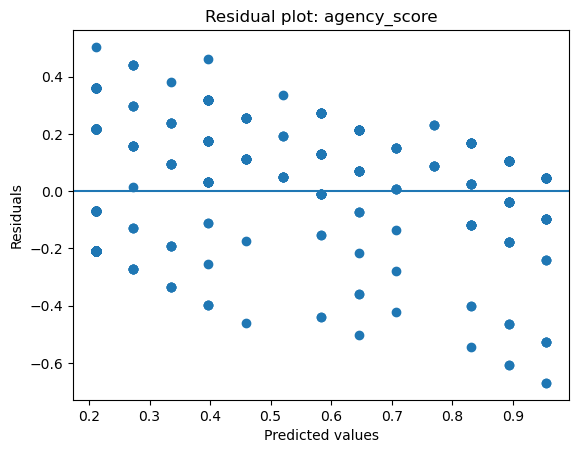

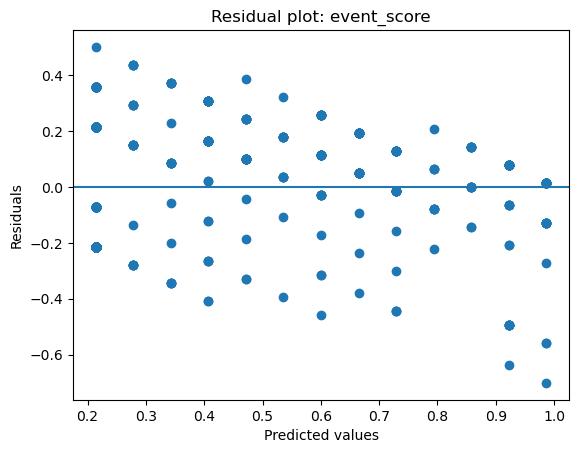

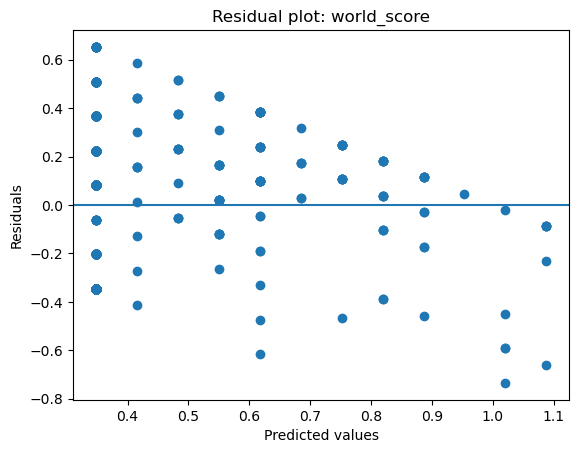

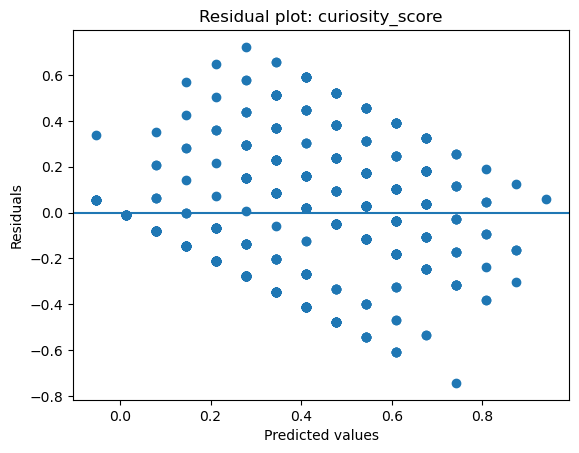

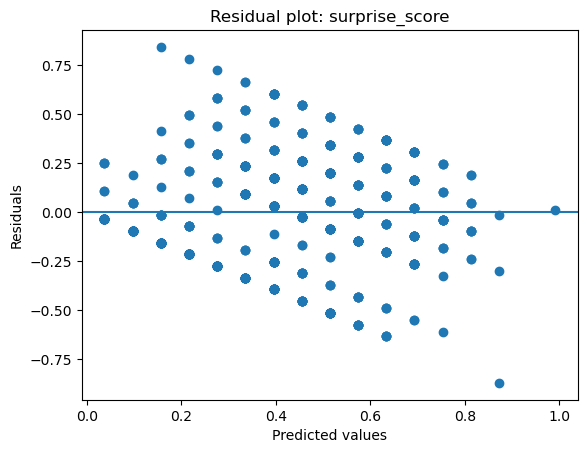

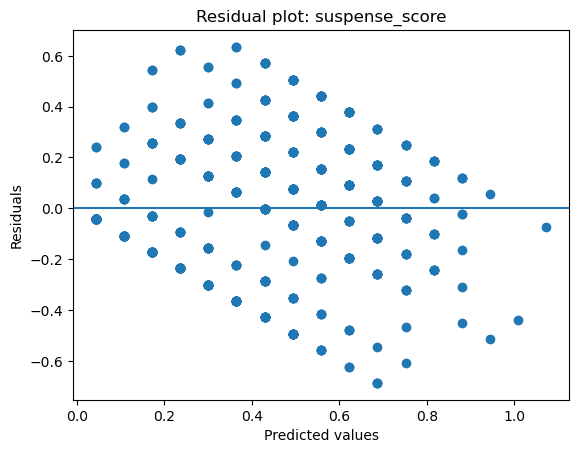

In [7]:
for var in independent_vars:

    X = data[[var]]
    y = dependent

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    residuals = y - predictions

    plt.figure()
    plt.scatter(predictions, residuals)
    plt.axhline(y=0)
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual plot: {var}")
    plt.show()

In [8]:
for var in independent_vars:

    X = data[[var]]
    y = dependent

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)

    residuals = y - predictions

    shapiro_test = stats.shapiro(residuals)

    print(f"{var} Shapiro test:", shapiro_test)

agency_score Shapiro test: ShapiroResult(statistic=np.float64(0.9433870313864505), pvalue=np.float64(1.2397856766787667e-14))
event_score Shapiro test: ShapiroResult(statistic=np.float64(0.9426995145578435), pvalue=np.float64(9.875589868196972e-15))
world_score Shapiro test: ShapiroResult(statistic=np.float64(0.9143422733035236), pvalue=np.float64(3.122520751932677e-18))
curiosity_score Shapiro test: ShapiroResult(statistic=np.float64(0.9887298863187969), pvalue=np.float64(0.00010538841050247789))
surprise_score Shapiro test: ShapiroResult(statistic=np.float64(0.9955295255509528), pvalue=np.float64(0.07191333447916998))
suspense_score Shapiro test: ShapiroResult(statistic=np.float64(0.994187025887173), pvalue=np.float64(0.01790913418680829))
